<a href="https://colab.research.google.com/github/Boommook/cs539-botbuster/blob/main/consolidated.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [19]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [20]:
from pandas.core.dtypes import missing
## Load and inspect the dataset
df = pd.read_csv("../data/raw/twitter_human_bots_dataset.csv")

print("Shape:", df.shape)
df.head()
df.info()

print("Class counts: ")  
print(df["account_type"].value_counts())
print()
print(df["account_type"].value_counts(normalize=True))
"""
missing_cnts = df.isna().sum()
missing_prcnts = (df.isna().mean() * 100)
missing_summary = pd.DataFrame({
    "missing_count": missing_cnts,
    "missing_percentage": missing_prcnts
})

# sort the table to the cols w the most missing vals appear first
missing_summary.sort_values(by="missing_cnts", ascending=False)

# display only columns that contain at least one missing value.
display(missing_summary[missing_summary["missing_count"] > 0])
"""

Shape: (37438, 20)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37438 entries, 0 to 37437
Data columns (total 20 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Unnamed: 0                    37438 non-null  int64  
 1   created_at                    37438 non-null  object 
 2   default_profile               37438 non-null  bool   
 3   default_profile_image         37438 non-null  bool   
 4   description                   30181 non-null  object 
 5   favourites_count              37438 non-null  int64  
 6   followers_count               37438 non-null  int64  
 7   friends_count                 37438 non-null  int64  
 8   geo_enabled                   37438 non-null  bool   
 9   id                            37438 non-null  int64  
 10  lang                          29481 non-null  object 
 11  location                      37434 non-null  object 
 12  profile_background_image_url  32939 non-n

'\nmissing_cnts = df.isna().sum()\nmissing_prcnts = (df.isna().mean() * 100)\nmissing_summary = pd.DataFrame({\n    "missing_count": missing_cnts,\n    "missing_percentage": missing_prcnts\n})\n\n# sort the table to the cols w the most missing vals appear first\nmissing_summary.sort_values(by="missing_cnts", ascending=False)\n\n# display only columns that contain at least one missing value.\ndisplay(missing_summary[missing_summary["missing_count"] > 0])\n'

In [21]:
display(df.head())

,Unnamed: 0,created_at,default_profile,default_profile_image,description,favourites_count,followers_count,friends_count,geo_enabled,id,lang,location,profile_background_image_url,profile_image_url,screen_name,statuses_count,verified,average_tweets_per_day,account_age_days,account_type
0,0,2016-10-15 21:32:11,False,False,"Blame @xaiax, Inspired by @MakingInvisible, us...",4,1589,4,False,787405734442958848,en,unknown,http://abs.twimg.com/images/themes/theme1/bg.png,http://pbs.twimg.com/profile_images/7874121826...,best_in_dumbest,11041,False,7.870,1403,bot
1,1,2016-11-09 05:01:30,False,False,Photographing the American West since 1980. I ...,536,860,880,False,796216118331310080,en,Estados Unidos,http://abs.twimg.com/images/themes/theme1/bg.png,http://pbs.twimg.com/profile_images/8023296328...,CJRubinPhoto,252,False,0.183,1379,human
2,2,2017-06-17 05:34:27,False,False,Scruffy looking nerf herder and @twitch broadc...,3307,172,594,True,875949740503859204,en,"Los Angeles, CA",http://abs.twimg.com/images/themes/theme1/bg.png,http://pbs.twimg.com/profile_images/1278890453...,SVGEGENT,1001,False,0.864,1159,human
3,3,2016-07-21 13:32:25,True,False,Wife.Godmother.Friend.Feline Fanatic! Assistan...,8433,517,633,True,756119643622735875,en,"Birmingham, AL",NaN,http://pbs.twimg.com/profile_images/1284884924...,TinkerVHELPK5,1324,False,0.889,1489,human
4,4,2012-01-15 16:32:35,False,False,Loan coach at @mancity & Aspiring DJ,88,753678,116,True,464781334,en,"England, United Kingdom",http://abs.twimg.com/images/themes/theme1/bg.png,http://pbs.twimg.com/profile_images/9952566258...,JoleonLescott,4202,True,1.339,3138,human


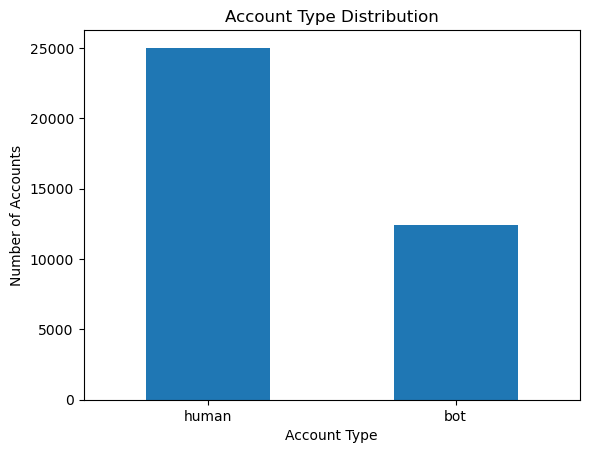

In [22]:
df["account_type"].value_counts().plot(kind="bar")

plt.title("Account Type Distribution")
plt.xlabel("Account Type")
plt.ylabel("Number of Accounts")
plt.xticks(rotation=0)
plt.show()

Numerical Feature Distributions

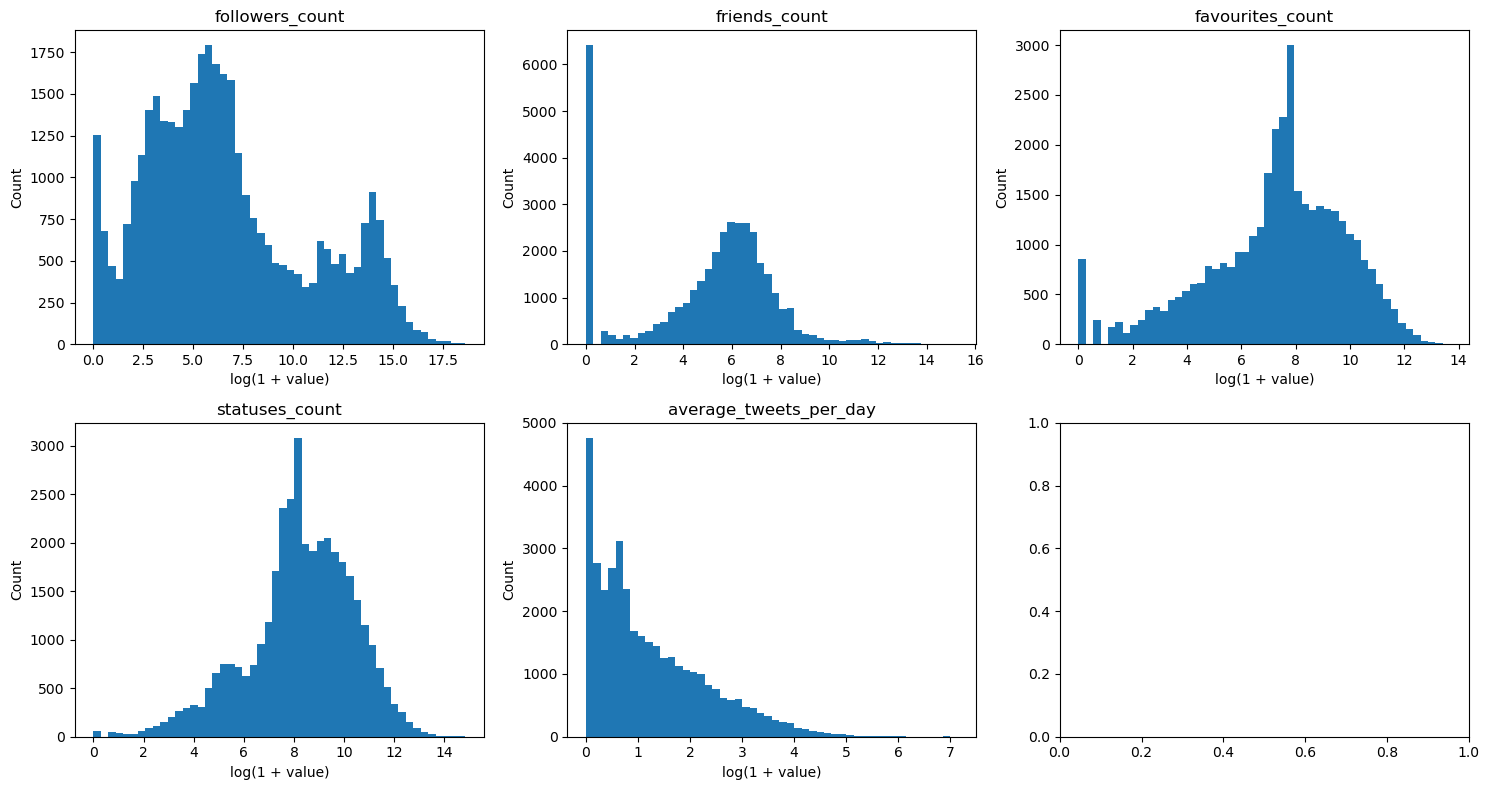

In [23]:
# I did this manually, but can be done dynamically too
numeric_cols = [
    "followers_count",
    "friends_count",
    "favourites_count",
    "statuses_count",
    "average_tweets_per_day"
]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for ax, col in zip(axes.flatten(), numeric_cols):
    # log1p reduces the effect of extremely large values
    ax.hist(np.log1p(df[col]), bins=50)
    ax.set_title(col)
    ax.set_xlabel("log(1 + value)")
    ax.set_ylabel("Count")

# need to hide unused graph I think

plt.tight_layout()
plt.show()

Numerical Feature Comparison btwn Humans and Bots

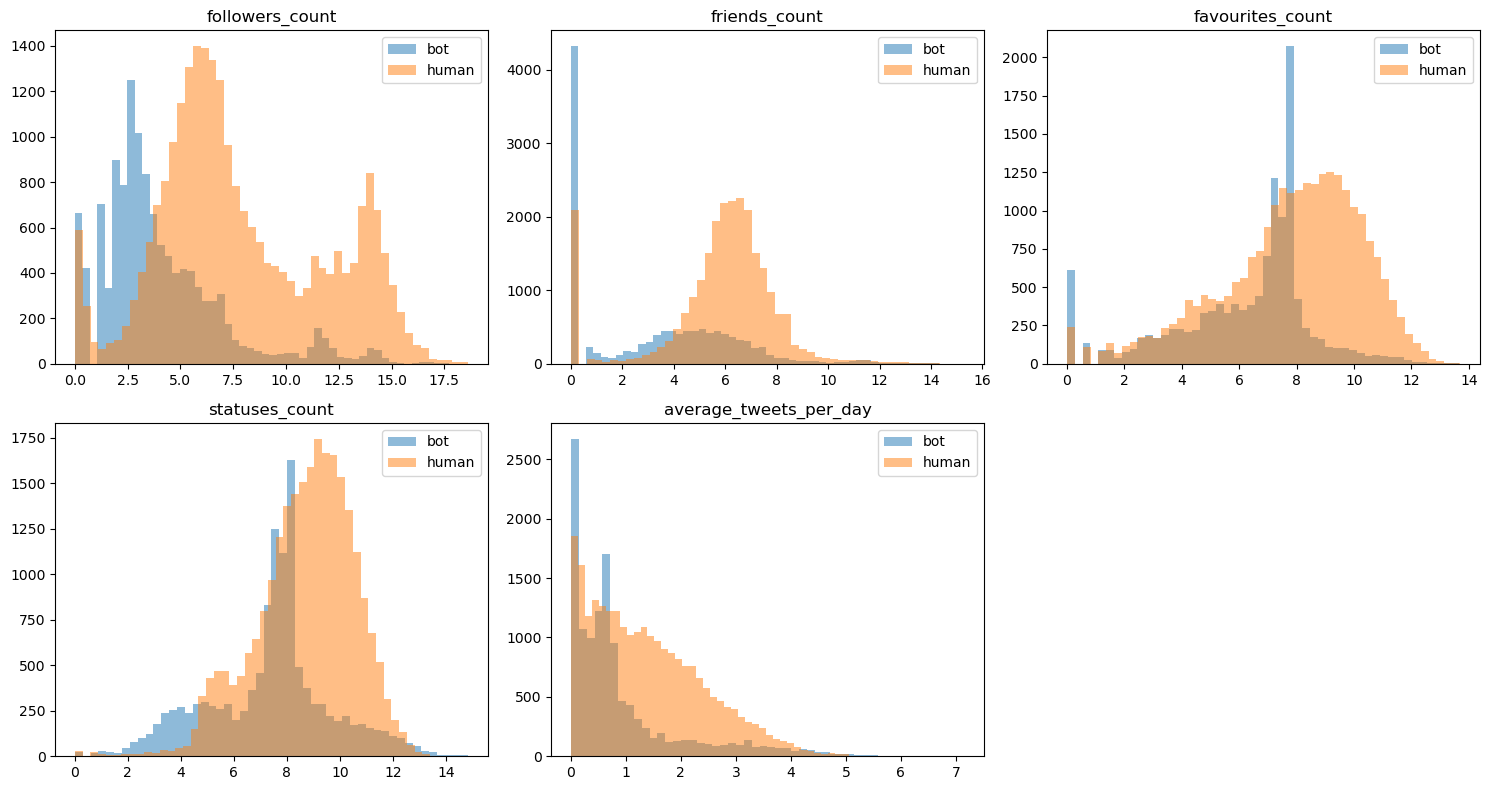

In [24]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for ax, col in zip(axes.flatten(), numeric_cols):
    for label, group in df.groupby("account_type"):
        ax.hist(
            np.log1p(group[col]),
            bins=50,
            alpha=0.5,
            label=label
        )

    ax.set_title(col)
    ax.legend()

# I think this hides the unused graph (TO DO: ADD ABOVE TOO)
for ax in axes.flatten()[len(numeric_cols):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

Compare Accounts Ages

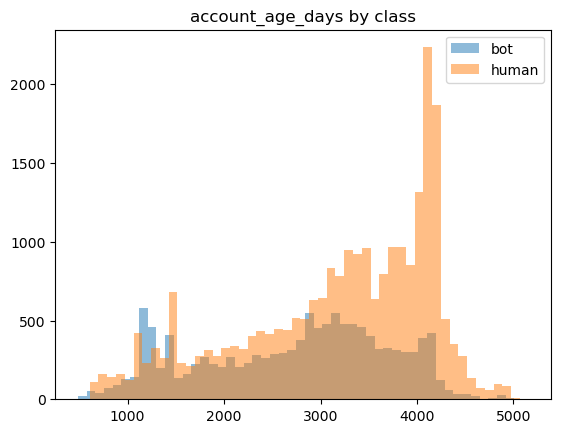

In [25]:
for label, group in df.groupby('account_type'):
    plt.hist(group['account_age_days'], bins=50, alpha=0.5, label=label)
plt.title('account_age_days by class')
plt.legend()
plt.show()

Box Plots by Type

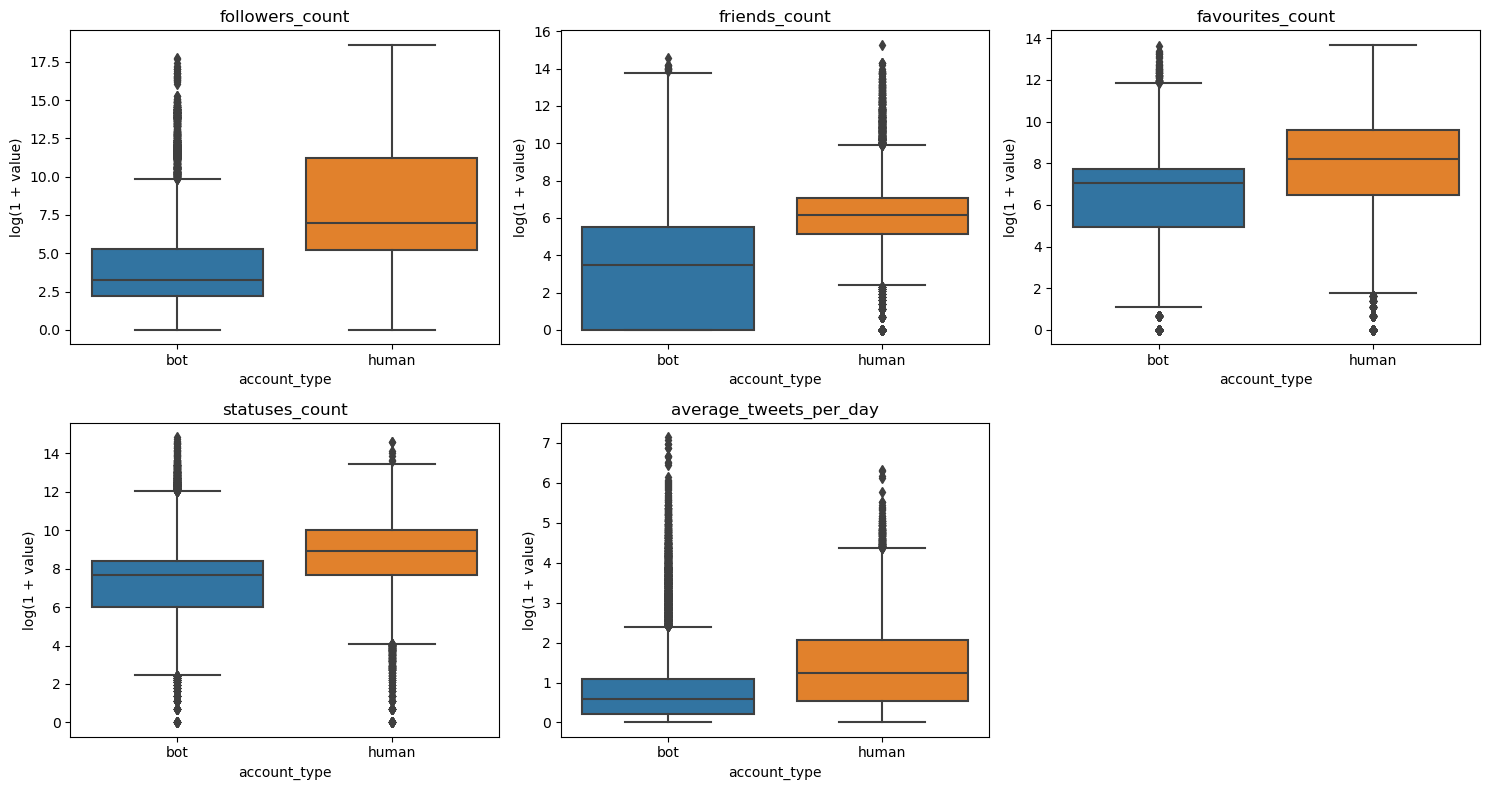

In [26]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for ax, col in zip(axes.flatten(), numeric_cols):
    sns.boxplot(
        data=df,
        x="account_type",
        y=np.log1p(df[col]),
        ax=ax
    )

    ax.set_title(col)
    ax.set_ylabel("log(1 + value)")

# hide unused graph
for ax in axes.flatten()[len(numeric_cols):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

Examine Boolean Feature Relationships

In [27]:
boolean_cols = [
    "default_profile",
    "default_profile_image",
    "geo_enabled",
    "verified"
]

for col in boolean_cols:
    print(f"\n{col}")

    display(
        pd.crosstab(
            df[col],
            df["account_type"],
            normalize="index"
        )
    )


default_profile


account_type,bot,human
default_profile,,
False,0.215674,0.784326
True,0.492430,0.507570



default_profile_image


account_type,bot,human
default_profile_image,,
False,0.326518,0.673482
True,0.686380,0.313620



geo_enabled


account_type,bot,human
geo_enabled,,
False,0.476843,0.523157
True,0.159044,0.840956



verified


account_type,bot,human
verified,,
False,0.405159,0.594841
True,0.041849,0.958151


Correlation Heatmap

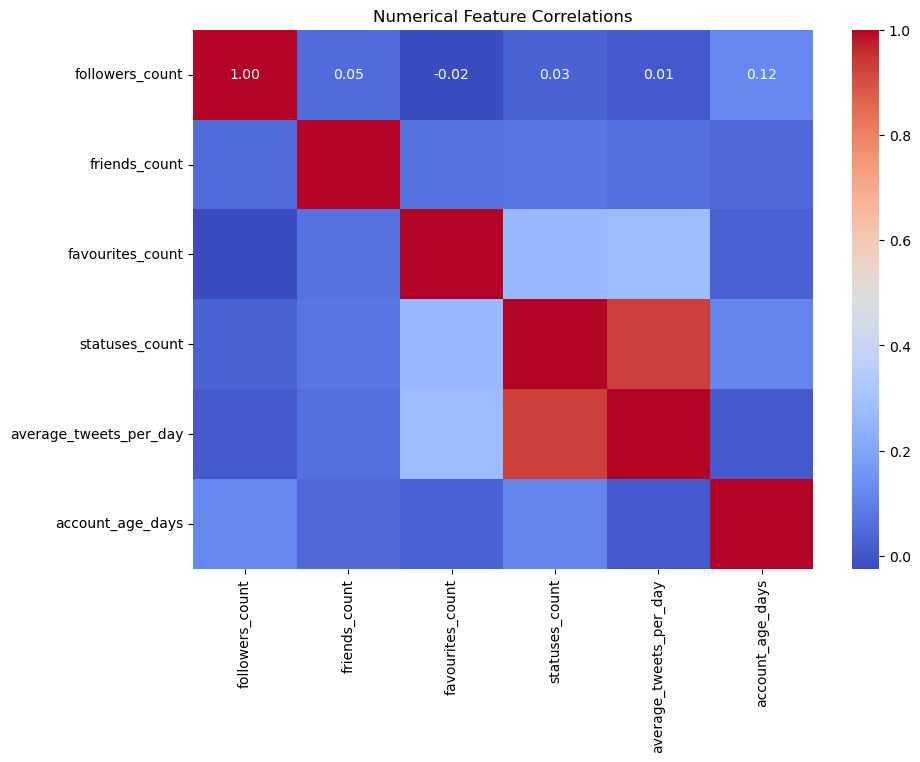

In [28]:
correlation_cols = numeric_cols + ["account_age_days"]

# we can change this if wanted
plt.figure(figsize=(10, 7))

sns.heatmap(
    df[correlation_cols].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Numerical Feature Correlations")
plt.show()

Clean, Remove, and Add Features to the Dataset. Note: This could be broken lol

In [31]:
def engineer_features(df, add_log_features=True):
    """
    Clean, remove, and add features to the dataset.
    Returens a copy of the dataset containing the newly engineered feats
    """
    model_df = df.copy()

    # convert the text target into int labels
    model_df["account_is_bot"] = (
        model_df["account_type"]
        .map({
            "human": 0,
            "bot": 1
        })
        .astype(int)
    )

    # ---------------------------------------------------------
    # Clean/remove features
    # ---------------------------------------------------------
    # remove columns that are identifiers, dupes, or unlikely to generalize
    model_df = model_df.drop(
        columns=[
            "Unnamed: 0",
            "id",
            "created_at",
            "profile_background_image_url",
            "profile_image_url",
            "location",
            "lang"
        ],
        errors="ignore"
    )

    # ---------------------------------------------------------
    # Mssing-val features
    # ---------------------------------------------------------
    model_df["description_missing"] = model_df["description"].isna()
    model_df["location_unknown"] = (
        df["location"].isna()
        | df["location"].fillna("").str.lower().eq("unknown")
    )
    model_df["language_missing"] = df["lang"].isna()

    # text-based feats
    description = df["description"].fillna("")
    screen_name = df["screen_name"].fillna("")

    # Description features
    model_df["description_length"] = description.str.len()
    model_df["description_word_count"] = description.str.split().str.len()
    model_df["description_mention_count"] = description.str.count(r"@\w+")
    model_df["description_hashtag_count"] = description.str.count(r"#\w+")
    model_df["description_digit_count"] = description.str.count(r"\d")
    model_df["description_exclamation_count"] = description.str.count("!")

    # Screen-name features
    model_df["screen_name_length"] = screen_name.str.len()
    model_df["screen_name_digit_count"] = screen_name.str.count(r"\d")
    model_df["screen_name_underscore_count"] = screen_name.str.count("_")

    # ---------------------------------------------------------
    # Drop raw text columns now that features are extracted
    # ---------------------------------------------------------
    model_df = model_df.drop(
        columns=["description", "screen_name"],
        errors="ignore"
    )

    # ---------------------------------------------------------
    # Log-transform skewed numeric features
    # ---------------------------------------------------------
    if add_log_features:
        skewed_cols = [
            "followers_count",
            "friends_count",
            "favourites_count",
            "statuses_count",
            "average_tweets_per_day",
        ]
        for col in skewed_cols:
            model_df[f"{col}_log"] = np.log1p(model_df[col])

    # ---------------------------------------------------------
    # Cast boolean columns to int (0/1) for modeling
    # ---------------------------------------------------------
    bool_cols = model_df.select_dtypes(include="bool").columns
    model_df[bool_cols] = model_df[bool_cols].astype(int)

    ## return completed dataframe
    return model_df

Final Check

In [34]:
model_df = engineer_features(df,  add_log_features=False)

print("Shape:", model_df.shape)

print("\nMissing values:")
print(model_df.isnull().sum().sort_values(ascending=False).head())

display(model_df.head())
model_df.dtypes.value_counts()

Shape: (37438, 24)

Missing values:
default_profile                  0
default_profile_image            0
screen_name_digit_count          0
screen_name_length               0
description_exclamation_count    0
dtype: int64


,default_profile,default_profile_image,favourites_count,followers_count,friends_count,geo_enabled,statuses_count,verified,average_tweets_per_day,account_age_days,...,language_missing,description_length,description_word_count,description_mention_count,description_hashtag_count,description_digit_count,description_exclamation_count,screen_name_length,screen_name_digit_count,screen_name_underscore_count
0,0,0,4,1589,4,0,11041,0,7.870,1403,...,0,129,18,2,0,0,0,15,0,2
1,0,0,536,860,880,0,252,0,0.183,1379,...,0,160,24,0,0,4,0,12,0,0
2,0,0,3307,172,594,1,1001,0,0.864,1159,...,0,81,10,2,0,0,0,8,0,0
3,1,0,8433,517,633,1,1324,0,0.889,1489,...,0,97,9,0,0,0,1,13,1,0
4,0,0,88,753678,116,1,4202,1,1.339,3138,...,0,36,7,1,0,0,0,13,0,0


int64      22
float64     1
object      1
Name: count, dtype: int64

In [35]:
from sklearn.model_selection import train_test_split

model_df_linear = engineer_features(df, add_log_features=True)

Xl = model_df_linear.drop(columns=["account_type", "account_is_bot"])
yl = model_df_linear["account_is_bot"]

Xl_train, Xl_test, yl_train, yl_test = train_test_split(
    Xl, yl, test_size=0.2, stratify=y, random_state=42
)

print("Train shape:", Xl_train.shape)
print("Test shape:", Xl_test.shape)
print("Train class balance:\n", yl_train.value_counts(normalize=True))
print("Test class balance:\n", yl_test.value_counts(normalize=True))

Train shape: (29950, 27)
Test shape: (7488, 27)
Train class balance:
 account_is_bot
0    0.668114
1    0.331886
Name: proportion, dtype: float64
Test class balance:
 account_is_bot
0    0.668136
1    0.331864
Name: proportion, dtype: float64


In [37]:
#----------------------- Baseline model- LogisticRegression __________________
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

# Scale features

scaler = StandardScaler()

Xl_train_scaled = scaler.fit_transform(Xl_train)   # fit + transform on train
Xl_test_scaled = scaler.transform(Xl_test)         # only transform on test


# Train logistic regression on scaled data

log_reg = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
log_reg.fit(Xl_train_scaled, yl_train)

yl_pred = log_reg.predict(Xl_test_scaled)

print(classification_report(yl_test, yl_pred, target_names=['human', 'bot']))
print(confusion_matrix(yl_test, y_pred))

              precision    recall  f1-score   support

       human       0.90      0.78      0.83      5003
         bot       0.65      0.82      0.72      2485

    accuracy                           0.79      7488
   macro avg       0.77      0.80      0.78      7488
weighted avg       0.81      0.79      0.80      7488

[[3905 1098]
 [ 458 2027]]


In [38]:
model_df = engineer_features(df, add_log_features=False)

X = model_df.drop(columns=["account_type", "account_is_bot"])
y = model_df["account_is_bot"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

In [43]:
#------------------------------- Random Forest-----------------------

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix


rf = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)   # note: using the *unscaled* X_train, not the scaled version

y_pred_rf = rf.predict(X_test)

print(classification_report(y_test, y_pred_rf, target_names=['human', 'bot']))
print(confusion_matrix(y_test, y_pred_rf))

              precision    recall  f1-score   support

       human       0.88      0.94      0.91      5003
         bot       0.87      0.74      0.80      2485

    accuracy                           0.88      7488
   macro avg       0.87      0.84      0.86      7488
weighted avg       0.88      0.88      0.87      7488

[[4726  277]
 [ 647 1838]]


### accuracy imroved from 0.79 to 0.88

### bot precision imporved from 0.65 yo 0.87



In [40]:
#rf.predict(X_test)
probs = rf.predict_proba(X_test)
print(probs[:5])  # first 5 accounts' [P(human), P(bot)]

[[0.07  0.93 ]
 [0.79  0.21 ]
 [0.78  0.22 ]
 [0.005 0.995]
 [0.635 0.365]]


In [45]:
#------------------------ Saving Random Forest (rf) model ----------------------
import joblib
import os

os.makedirs('../models', exist_ok=True)

joblib.dump(rf, '../models/bot_detector_rf.pkl')

feature_columns = X_train.columns.tolist()
joblib.dump(feature_columns, '../models/feature_columns.pkl')


print("Saved model and feature columns.")

Saved model and feature columns.


In [46]:
 # ------------------------  building the demo data  ----------------------------------------
# building the dataset the dashboard will show and let users pick from it.

demo_df = X_test.copy()
demo_df['true_label'] = df.loc[X_test.index, 'account_type']
demo_df['screen_name'] = df.loc[X_test.index, 'screen_name']
demo_df['twitter_id'] = df.loc[X_test.index, 'id']

demo_df.to_csv('../data/processed/demo_accounts.csv', index=True)
print("Demo shape:", demo_df.shape)
demo_df.head()

Demo shape: (7488, 25)


,default_profile,default_profile_image,favourites_count,followers_count,friends_count,geo_enabled,statuses_count,verified,average_tweets_per_day,account_age_days,...,description_mention_count,description_hashtag_count,description_digit_count,description_exclamation_count,screen_name_length,screen_name_digit_count,screen_name_underscore_count,true_label,screen_name,twitter_id
36639,1,0,480,18,0,0,96,0,0.027,3593,...,0,0,0,0,8,0,1,bot,zul_mark,204204239
18749,1,0,9627,23,126,0,2056,0,1.162,1769,...,0,0,0,1,9,0,0,human,TheToKuma,3970040302
25745,0,0,8204,32,72,0,1259,0,0.783,1607,...,0,0,0,0,10,1,0,human,PikaPixie1,713439734949941248
36883,1,0,2086,4,0,0,2874,0,0.966,2975,...,0,0,0,0,10,0,1,bot,LuCkii_dlb,619966533
18699,1,0,1295,99,439,1,684,0,0.173,3964,...,0,0,0,0,13,0,0,human,digitallmusic,81658042


In [17]:
import shap

# use a small sample to prototype quickly
X_sample = X_test.iloc[:50]

explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_sample)

print(type(shap_values))
print(shap.__version__)

if isinstance(shap_values, list):
    print(len(shap_values))
    print(shap_values[0].shape)
else:
    print(shap_values.shape)

<class 'list'>
0.44.1
2
(50, 27)


In [18]:
account_index = 0  # first row in X_sample

account_shap_values = shap_values[1][account_index]  # array of 27 numbers  #shap_values[1] for bots, shap_values[0] human
feature_names = X_sample.columns

# pair each feature with its SHAP value, sorted by impact
import pandas as pd
explanation = pd.Series(account_shap_values, index=feature_names)
explanation.sort_values(key=abs, ascending=False).head(10)

followers_count_log           0.077290
followers_count               0.075823
friends_count_log             0.073181
friends_count                 0.052150
favourites_count              0.033657
average_tweets_per_day        0.026815
favourites_count_log          0.023370
average_tweets_per_day_log    0.022109
statuses_count                0.018504
geo_enabled                   0.018422
dtype: float64

In [19]:
import pandas as pd

importances = pd.Series(rf.feature_importances_, index=X_train.columns)
importances.sort_values(ascending=False).head(10)

followers_count_log       0.118873
followers_count           0.109324
favourites_count          0.086559
friends_count_log         0.086554
favourites_count_log      0.081842
friends_count             0.073048
account_age_days          0.059474
statuses_count            0.053669
statuses_count_log        0.052239
average_tweets_per_day    0.049251
dtype: float64

### The important predictors are followers_count (followers_count_log+followers_count), friends_counts and favourites count

In [19]:
#------------------------------ XGBoost _________________________
import xgboost
print(xgboost.__version__)

3.2.0


In [22]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix


scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb = XGBClassifier(
    n_estimators=200,
    max_depth=8,
    learning_rate=0.05,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric='logloss',
    n_jobs=-1
)

xgb.fit(X_train, y_train)   # unscaled data, same as Random Forest 

y_pred_xgb = xgb.predict(X_test)

print(classification_report(y_test, y_pred_xgb, target_names=['human', 'bot']))
print(confusion_matrix(y_test, y_pred_xgb))

              precision    recall  f1-score   support

       human       0.91      0.90      0.91      5003
         bot       0.81      0.82      0.82      2485

    accuracy                           0.88      7488
   macro avg       0.86      0.86      0.86      7488
weighted avg       0.88      0.88      0.88      7488

[[4517  486]
 [ 436 2049]]


### XGBoost doesn't seem to make a significat improvement compared to random forest.